<a href="https://colab.research.google.com/github/AI-is-out-there/neural-network-skills-review/blob/main/vanilla-code/task2-1_ecg_supervised_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECG Heartbeat Classification with a 1D CNN

Vanilla notebook for task 2.1. It shows a compact supervised pipeline for ECG heartbeat classification on the `ECG5000`-based dataset stored in this repository.

## Why a 1D Convolutional Neural Network?

ECG heartbeat segments are short **univariate time series** (~140 time steps).
A 1D CNN is a natural first choice for several reasons:

1. **Local pattern extraction** — convolutional filters learn to detect
   morphological features (QRS complex, T-wave, ST-segment deviations) without
   manual feature engineering.
2. **Translation invariance** — pooling layers make the model robust to small
   temporal shifts in waveform alignment.
3. **Efficiency** — 1D convolutions are lightweight and train quickly even on
   CPU, making this approach ideal for a compact educational dataset.
4. **Class weighting** — the ECG5000 dataset is heavily imbalanced (the
   "Normal" class accounts for ~58% of samples, while "UB" has fewer than 1%).
   Cross-entropy loss with inverse-frequency class weights helps the network
   pay attention to rare arrhythmia types.

Alternatives such as RNNs or Transformers are viable but add complexity without
a clear benefit on 140-step signals with 5 000 samples.

## План

1. Загрузить и проверить данные
2. Выполнить стратифицированное разбиение train / validation / test
3. Нормализовать сигналы
4. Обучить простую `1D CNN`
5. Оценить `Accuracy`, `macro F1` и построить матрицу ошибок

# Install and load libraries

In [1]:
# If you run this notebook in Colab or a clean environment, uncomment the line below.
!pip install torch scikit-learn seaborn 


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cpu


# Load dataset

The ECG5000 dataset contains 5 000 heartbeat segments, each 140 time steps
long, labelled as one of five classes: **N** (Normal), **R-on-T PVC**,
**PVC**, **SP or EB** (Supra-ventricular Premature or Ectopic Beat), and
**UB** (Unclassifiable Beat).  The class distribution is highly imbalanced.

In [3]:
data_path = Path('../dataset/task2_1-ecg5000-heartbeat-classification.csv')
if not data_path.exists():
    data_path = Path('dataset/task2_1-ecg5000-heartbeat-classification.csv')

df = pd.read_csv(data_path)
feature_cols = [c for c in df.columns if c.startswith('t_')]

X = df[feature_cols].to_numpy(dtype=np.float32)
y = df['label_id'].to_numpy(dtype=np.int64) - 1
label_names = [
    'N',
    'R-on-T PVC',
    'PVC',
    'SP or EB',
    'UB',
]

print(df.shape)
display(df.head())
print(df['label_name'].value_counts())

(5000, 143)


,source_split,label_id,label_name,t_000,t_001,t_002,t_003,t_004,t_005,t_006,...,t_130,t_131,t_132,t_133,t_134,t_135,t_136,t_137,t_138,t_139
0,train,1,N,-0.112522,-2.827204,-3.773897,-4.349751,-4.376041,-3.474986,-2.181408,...,0.160348,0.792168,0.933541,0.796958,0.578621,0.257740,0.228077,0.123431,0.925286,0.193137
1,train,1,N,-1.100878,-3.996840,-4.285843,-4.506579,-4.022377,-3.234368,-1.566126,...,0.560327,0.538356,0.656881,0.787490,0.724046,0.555784,0.476333,0.773820,1.119621,-1.436250
2,train,1,N,-0.567088,-2.593450,-3.874230,-4.584095,-4.187449,-3.151462,-1.742940,...,1.284825,0.886073,0.531452,0.311377,-0.021919,-0.713683,-0.532197,0.321097,0.904227,-0.421797
3,train,1,N,0.490473,-1.914407,-3.616364,-4.318823,-4.268016,-3.881110,-2.993280,...,0.491173,0.350816,0.499111,0.600345,0.842069,0.952074,0.990133,1.086798,1.403011,-0.383564
4,train,1,N,0.800232,-0.874252,-2.384761,-3.973292,-4.338224,-3.802422,-2.534510,...,0.966606,1.148884,0.958434,1.059025,1.371682,1.277392,0.960304,0.971020,1.614392,1.421456


label_name
N             2919
R-on-T PVC    1767
SP or EB       194
PVC             96
UB              24
Name: count, dtype: int64


# Visualise ECG signals

One representative heartbeat per class helps build intuition about the
morphological differences the CNN must learn.  Normal beats (N) have a clean
QRS complex and T-wave; arrhythmia types show characteristic deviations in
amplitude, timing, or waveform shape.

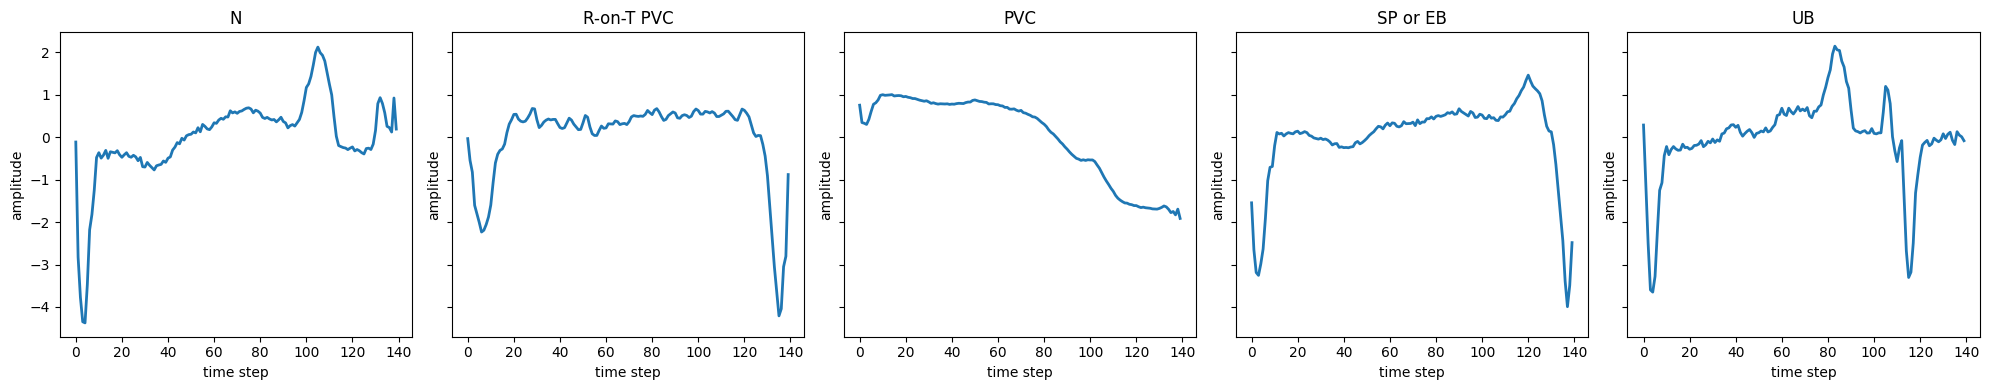

In [4]:
fig, axes = plt.subplots(1, len(label_names), figsize=(20, 4), sharey=True)
for ax, class_id in zip(axes, range(len(label_names))):
    idx = np.where(y == class_id)[0][0]
    ax.plot(X[idx], lw=2)
    ax.set_title(label_names[class_id])
    ax.set_xlabel('time step')
    ax.set_ylabel('amplitude')
plt.tight_layout()

### Observations

- **N (Normal)** — typical ECG morphology with a sharp QRS spike and smooth
  baseline.  This is the majority class.
- **R-on-T PVC** — the premature ventricular complex falls on the T-wave of
  the preceding beat, creating a distinctive wide, distorted waveform.
- **PVC** — a premature ventricular contraction with altered QRS shape but
  different timing from R-on-T PVC.
- **SP or EB** — supraventricular premature or ectopic beats with subtle
  morphological changes that are harder to distinguish from Normal.
- **UB** — unclassifiable beats with the fewest samples; noisy or ambiguous
  morphology.

The visual similarity between minority classes (PVC, SP/EB, UB) and Normal
explains why classification of rare arrhythmias is challenging.

# Preprocessing, model, and training

**Data split:** stratified 70 / 15 / 15 into train, validation, and test sets
to preserve class proportions.

**Normalisation:** `StandardScaler` fitted on the training set only — each
time step is independently z-scored.

**Architecture:** three 1D convolutional blocks (16 → 32 → 64 filters) with
ReLU activations and max-pooling, followed by adaptive average pooling and a
two-layer classifier head.

**Training:** Adam optimiser, cross-entropy loss with **inverse-frequency class
weights** to counter the severe class imbalance, early stopping on validation
macro F1.

In [5]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.1765, stratify=y_trainval, random_state=SEED
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

def to_loader(features, targets, batch_size=128, shuffle=False):
    tensor_x = torch.tensor(features[:, None, :], dtype=torch.float32)
    tensor_y = torch.tensor(targets, dtype=torch.long)
    return DataLoader(TensorDataset(tensor_x, tensor_y), batch_size=batch_size, shuffle=shuffle)

train_loader = to_loader(X_train, y_train, shuffle=True)
val_loader = to_loader(X_val, y_val)
test_loader = to_loader(X_test, y_test)

print('train:', X_train.shape, 'val:', X_val.shape, 'test:', X_test.shape)

train: (3499, 140) val: (751, 140) test: (750, 140)


In [6]:
class ECGClassifier(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

class_counts = np.bincount(y_train)
class_weights = len(y_train) / (len(class_counts) * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)

model = ECGClassifier(n_classes=len(label_names)).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

model

ECGClassifier(
  (features): Sequential(
    (0): Conv1d(1, 16, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): ReLU()
    (8): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.2, inplace=False)
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=5, bias=True)
  )
)

In [7]:
def run_epoch(loader, train_mode=False):
    model.train(train_mode)
    total_loss = 0.0
    preds_all, targets_all = [], []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        if train_mode:
            optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        if train_mode:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * len(xb)
        preds_all.extend(logits.argmax(dim=1).detach().cpu().numpy())
        targets_all.extend(yb.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    f1 = f1_score(targets_all, preds_all, average='macro')
    acc = accuracy_score(targets_all, preds_all)
    return avg_loss, acc, f1

history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
best_state = None
best_val_f1 = -1
patience = 5
wait = 0

for epoch in range(1, 26):
    train_loss, train_acc, train_f1 = run_epoch(train_loader, train_mode=True)
    val_loss, val_acc, val_f1 = run_epoch(val_loader, train_mode=False)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)
    print(f'epoch={epoch:02d} train_loss={train_loss:.4f} val_loss={val_loss:.4f} train_f1={train_f1:.4f} val_f1={val_f1:.4f}')

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print('Early stopping')
            break

model.load_state_dict(best_state)

epoch=01 train_loss=1.6088 val_loss=1.6062 train_f1=0.0293 val_f1=0.0680


epoch=02 train_loss=1.5992 val_loss=1.5943 train_f1=0.1037 val_f1=0.1634


epoch=03 train_loss=1.5795 val_loss=1.5578 train_f1=0.2776 val_f1=0.3563


epoch=04 train_loss=1.5245 val_loss=1.4723 train_f1=0.3681 val_f1=0.3977


epoch=05 train_loss=1.4542 val_loss=1.3926 train_f1=0.3693 val_f1=0.3710


...

epoch=22 train_loss=1.0586 val_loss=1.0451 train_f1=0.4717 val_f1=0.5771


epoch=23 train_loss=1.0551 val_loss=0.9890 train_f1=0.4814 val_f1=0.5211


epoch=24 train_loss=1.0062 val_loss=0.9912 train_f1=0.4817 val_f1=0.5642


epoch=25 train_loss=1.0196 val_loss=0.9664 train_f1=0.4810 val_f1=0.5186
Early stopping


<All keys matched successfully>

# Evaluate model

We examine the training dynamics (loss and macro F1 curves), then evaluate the
best checkpoint on the held-out test set using per-class precision/recall and
the confusion matrix.

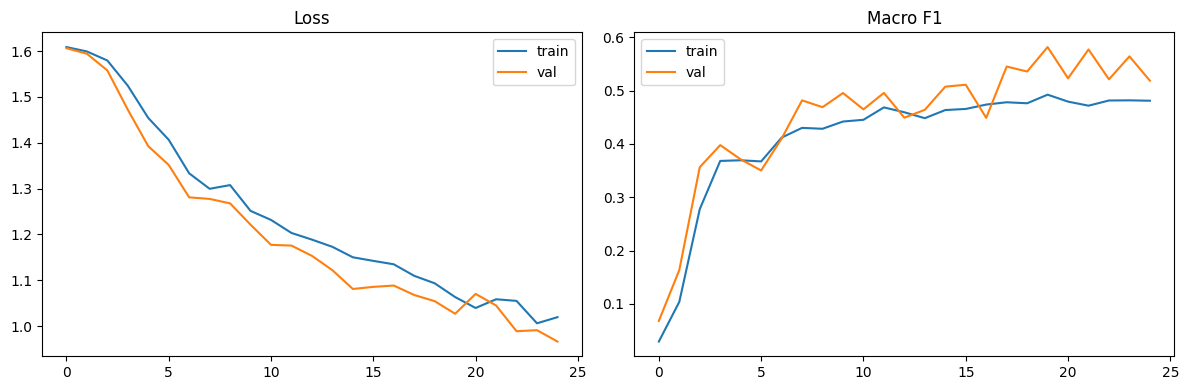

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history['train_f1'], label='train')
axes[1].plot(history['val_f1'], label='val')
axes[1].set_title('Macro F1')
axes[1].legend()
plt.tight_layout()

In [9]:
model.eval()
test_preds, test_targets = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        logits = model(xb.to(device))
        test_preds.extend(logits.argmax(dim=1).cpu().numpy())
        test_targets.extend(yb.numpy())

test_acc = accuracy_score(test_targets, test_preds)
test_f1 = f1_score(test_targets, test_preds, average='macro')
print('Test accuracy:', round(test_acc, 4))
print('Test macro F1:', round(test_f1, 4))
print(classification_report(test_targets, test_preds, target_names=label_names))

Test accuracy: 0.8613
Test macro F1: 0.517
              precision    recall  f1-score   support

           N       1.00      0.92      0.95       438
  R-on-T PVC       0.94      0.84      0.89       265
         PVC       0.18      0.71      0.29        14
    SP or EB       0.27      0.41      0.32        29
          UB       0.09      0.25      0.13         4

    accuracy                           0.86       750
   macro avg       0.50      0.63      0.52       750
weighted avg       0.93      0.86      0.89       750



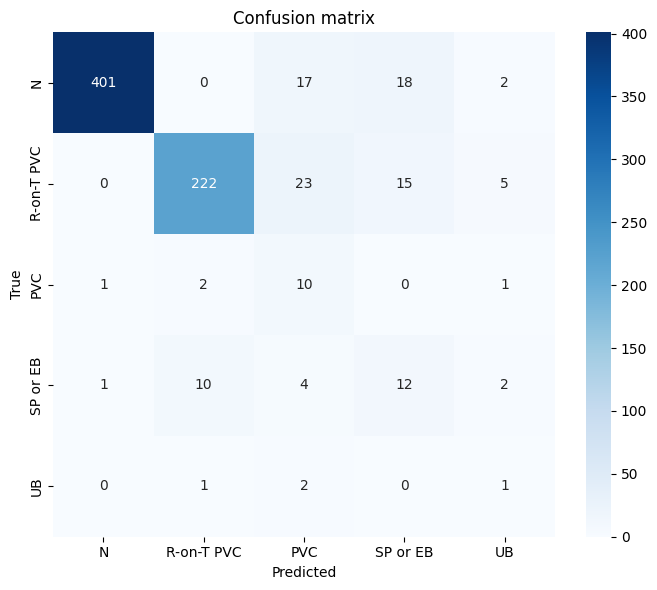

In [10]:
cm = confusion_matrix(test_targets, test_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion matrix')
plt.tight_layout()

# Conclusion

1. **The 1D CNN effectively classifies the two dominant classes** — Normal (N)
   and R-on-T PVC — with high precision and recall, demonstrating that
   convolutional filters can learn ECG morphological features automatically.

2. **Minority-class performance is limited.**  PVC, SP/EB, and especially UB
   have very few training samples.  Despite inverse-frequency class weighting,
   these classes show low F1 scores.  This is a common challenge in medical
   time-series classification where pathological events are rare.

3. **Possible improvements:**
   - **Data augmentation** (time-warping, jittering, magnitude scaling) to
     synthetically increase minority-class representation.
   - **Focal loss** or other loss functions designed for extreme imbalance.
   - **More expressive architectures** — residual 1D CNN, GRU/LSTM, or a
     Transformer encoder — may capture longer-range dependencies.
   - **Oversampling / SMOTE** applied in the signal domain.
   - **Threshold tuning** on the validation set to improve recall for
     clinically critical arrhythmia types at the cost of some overall accuracy.

4. **Clinical context.**  In a real deployment, missing a dangerous arrhythmia
   (false negative for PVC or R-on-T PVC) is far more costly than a false
   alarm.  The model should be evaluated with clinical cost matrices, not just
   macro F1.